<a href="https://colab.research.google.com/github/Rutuja-111223/PBEL_Project-Tomato-and-potato-leaf-diesesae-detection-using-cnn-/blob/main/PotatoTomatoLeafDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


https://www.kaggle.com/datasets/emmarex/plantdisease/data

In [ ]:
#@title IMPORTS
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt


In [ ]:
#@title CONSTANTS
BATCH_SIZE = 16          # ✅ reduced
IMAGE_SIZE = 128         # ✅ reduced (major RAM saver)
EPOCHS = 10              # ✅ reduce for testing
CHANNELS = 3



In [ ]:
# ================================
#@title DATA PREPROCESSING
# ================================
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/plantdisease/PlantVillage",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names
print("Classes:", class_names)
print("Total Classes:", len(class_names))


#  REDUCE DATASET SIZE
dataset = dataset.take(500)


# 5. SPLIT DATASET
def get_dataset_partition(ds, train_split=0.8, val_split=0.1, test_split=0.1):
    ds_size = len(ds)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partition(dataset)


# 6. PERFORMANCE
train_ds = train_ds.shuffle(500).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# PREPROCESSING
resize_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
])


Found 20638 files belonging to 15 classes.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Total Classes: 15


In [ ]:

#@title MODEL TRAINING
# Get number of output classes (e.g., number of disease categories)
n_classes = len(class_names)

# Create a Sequential CNN model
model = tf.keras.Sequential([
    resize_rescale,  # Resize images + normalize pixel values (0–255 → 0–1)
    data_augmentation,  # Apply data augmentation (flip, rotate
    #16 filter
    layers.Conv2D(16, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(), # Reduce image size (downsampling) to make model faster

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(n_classes, activation='softmax')
])

model.build(input_shape=(None, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
model.summary()


# COMPILE MODEL
model.compile(
    optimizer='adam',# Adam optimizer adjusts learning rate automatically
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']  # Track accuracy during training
)

# TRAIN MODEL # Train the model using training dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,# Validation dataset (used to check performance during training)
    epochs=EPOCHS # Number of times model sees entire dataset
)

# EVALUATE MODEL
score = model.evaluate(test_ds) # Evaluate model performance on unseen test dataset
print("Test Accuracy:", score[1]) # Print test accuracy (how well model performs on new data)



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,073,199 (4.09 MB)

 Trainable params: 1,073,199 (4.09 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 146s 301ms/step - accuracy: 0.3064 - loss: 2.1703 - val_accuracy: 0.4462 - val_loss: 1.7329
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 195s 324ms/step - accuracy: 0.4995 - loss: 1.5418 - val_accuracy: 0.5913 - val_loss: 1.2179
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 130s 298ms/step - accuracy: 0.5648 - loss: 1.3223 - val_accuracy: 0.6612 - val_loss: 1.0366
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 124s 295ms/step - accuracy: 0.6028 - loss: 1.1835 - val_accuracy: 0.7387 - val_loss: 0.7898
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 123s 294ms/step - accuracy: 0.6212 - loss: 1.1087 - val_accuracy: 0.7538 - val_loss: 0.7138
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 126s 299ms/step - accuracy: 0.6556 - loss: 1.0174 - val_accuracy: 0.7013 - val_loss: 0.8209
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 141s 297ms/step - accuracy: 0.6747 - loss: 0.9441 - val_accuracy: 0.7588 - val_loss: 0.6944
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 144s 301ms/step - accuracy: 0.6844 -

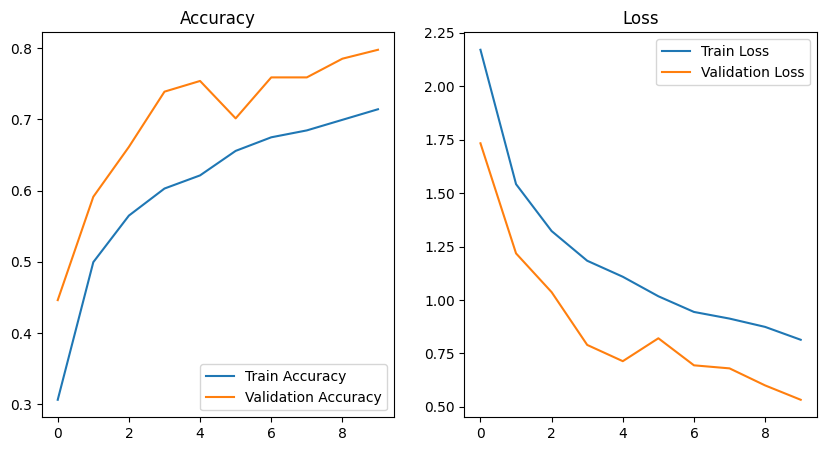

In [ ]:
#@title PLOT RESULTS
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 5))

#Shows how well model is learning
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

#Shows the error
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()



In [ ]:
# SAVE MODEL
model.save("plant_disease_model.h5")

In [ ]:
# model.save("plant_disease_model.h5")

In [ ]:
import json

with open("class_names.json", "w") as f:
    json.dump(class_names, f)   ## Convert Python list 'class_names' into JSON format

print("✅ class_names.json created")

✅ class_names.json created


In [ ]:
import os
print(os.listdir())

['.config', 'plant_disease_model.h5', 'class_names.json', 'sample_data']


In [ ]:
!pip install streamlit pyngrok tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 51.9 MB/s eta 0:00:00


In [ ]:
#creates a file named app.py
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import json

st.set_page_config(page_title="Potato and Tomato Leaf Disease Prediction", page_icon="🌿")

model = tf.keras.models.load_model("plant_disease_model.h5")

with open("class_names.json", "r") as f:
    class_names = json.load(f)

IMAGE_SIZE = 128

def clean_name(name):
    return name.replace("___", " ").replace("_", " ")

def predict_image(img):
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions)]

    return predicted_class

st.title(" Potato and Tomato Leaf Disease Prediction")

uploaded_file = st.file_uploader("Upload Image", type=["jpg","png","jpeg"])

if uploaded_file:
    image = Image.open(uploaded_file)
    st.image(image)

    if st.button("Predict"):
        pred = predict_image(image)
        st.success(f" Disease: {clean_name(pred)}")

Writing app.py


In [ ]:
from pyngrok import ngrok
ngrok.set_auth_token("3C7E1sTUCgzROiVOT5ri058LpjC_3aQTiQQyibe2tRYeaskXF")

ngrok.kill()
public_url = ngrok.connect(8501)
print("🌍 Live URL:", public_url)

!streamlit run app.py &



🌍 Live URL: NgrokTunnel: "https://impressionistically-metalliferous-hildegarde.ngrok-free.dev" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.66.244:8501

2026-04-15 17:32:17.583939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776274337.642438   20003 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776274337.660115   20003 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776274337.711732   20003 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid link

In [ ]:
!ls